# Import Libraries

Import the required Python libraries for data manipulation, visualization, and machine learning. These tools will help us analyze the dataset and build predictive models.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

Load the dataset into the notebook and preview its contents. This allows us to understand the structure of the data before cleaning, exploration, and model development.

In [8]:
housingData = pd.read_csv('Housing.csv')
print(housingData.shape)
housingData[['area','bedrooms','bathrooms','price']].head(10)

(545, 13)


,area,bedrooms,bathrooms,price
0,7420,4,2,13300000
1,8960,4,4,12250000
2,9960,3,2,12250000
3,7500,4,2,12215000
4,7420,4,1,11410000
5,7500,3,3,10850000
6,8580,4,3,10150000
7,16200,5,3,10150000
8,8100,4,1,9870000
9,5750,3,2,9800000


## Feature Selection and Missing Value Handling

Select the most relevant features for the prediction task and create a simplified dataset. Missing values are then replaced with the median of each column to ensure the dataset is complete and ready for model training.

In [24]:
# Select key features
features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

target = 'price'

# Use only selected columns
predictionModel = housingData[features + [target]].copy()

# Convert yes/no to numbers
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    predictionModel[col] = predictionModel[col].map({'yes': 1, 'no': 0})

# Fill missing values with median (numeric columns only)

predictionModel.fillna(
    predictionModel.median(numeric_only=True),
    inplace=True
)

print('Remaining missing values:', predictionModel.isnull().sum().sum())

Remaining missing values: 0


# Exploratory Data Analysis (EDA)

Explore the dataset to identify patterns, trends, and relationships between variables. Visualizations help us better understand the distribution of house prices and how key features may influence the target variable.

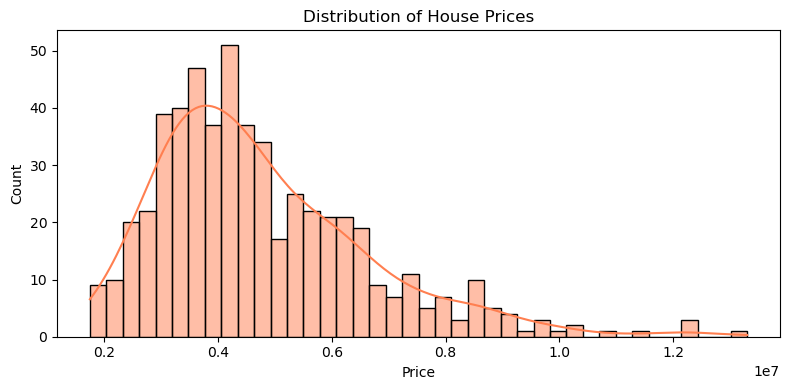

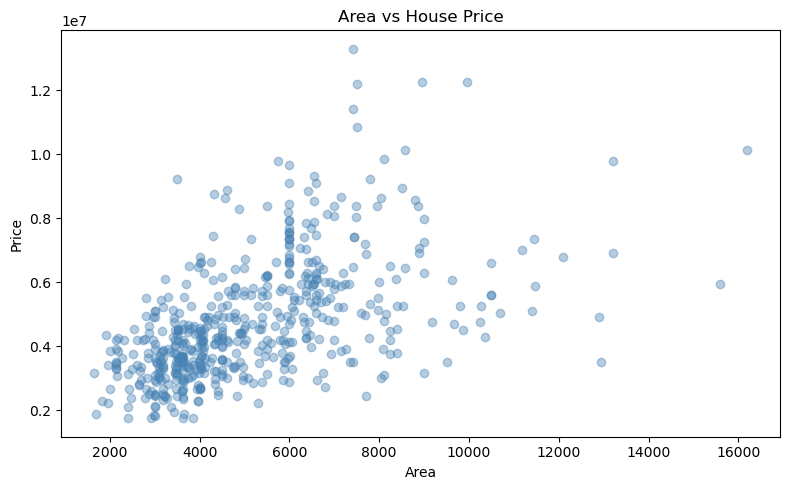

In [34]:
# House Price Distribution
plt.figure(figsize=(8,4))

sns.histplot(
    predictionModel['price'],
    bins=40,
    kde=True,
    color='coral'
)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.tight_layout()
plt.show()

# Area vs Price
plt.figure(figsize=(8,5))

plt.scatter(
    predictionModel['area'],
    predictionModel['price'],
    alpha=0.4,
    color='steelblue'
)

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs House Price')

plt.tight_layout()
plt.show()

#Prices are shown in scientific notation because Matplotlib automatically scales large values (in millions) for cleaner visualization instead of displaying full numbers.

# Train the Model

Divide the data into training and testing sets, then train a Gradient Boosting Regressor. This model captures complex relationships between features and the target variable, and is evaluated on test data to check how well it generalizes.

In [35]:
X = predictionModel[features]
y = predictionModel[target]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Gradient Boosting 
model = GradientBoostingRegressor(
    n_estimators=500,  
    learning_rate=0.05, 
    max_depth=3,        
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Model trained!')

Model trained!


# Model Evaluation

Assess the performance of the trained model using MAE, RMSE, and R² Score. These metrics indicate the average prediction error and how well the model fits the data.`

In [36]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: ${mae:,.0f}')
print(f'Root Mean Sq Error: ${rmse:,.0f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error: $986,120
Root Mean Sq Error: $1,331,352
R2 Score: 0.6493


# Actual vs Predicted Analysis

Visualize the model’s performance by comparing actual house prices with predicted values. This helps assess how closely the model’s predictions match real outcomes and identify any patterns of error.

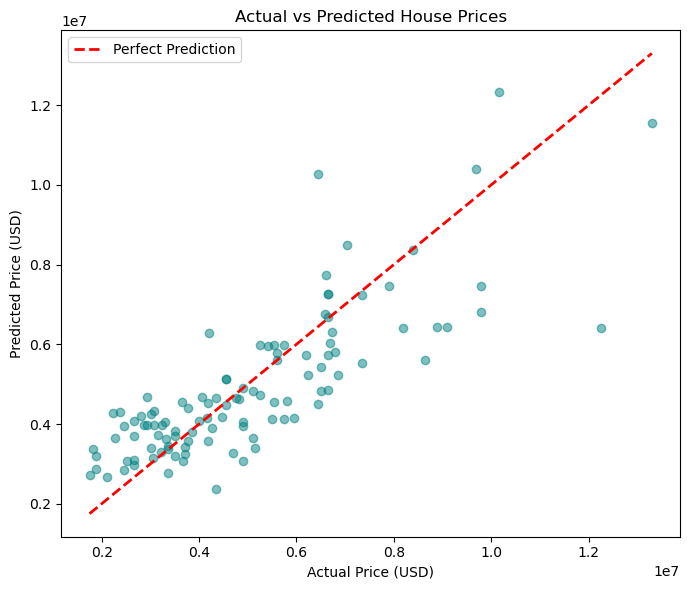

In [37]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend(); plt.tight_layout(); plt.show()

# Feature Importance

Identify and visualize the importance of each feature used in the Gradient Boosting model. This provides insight into which variables have the strongest impact on predicting house prices.

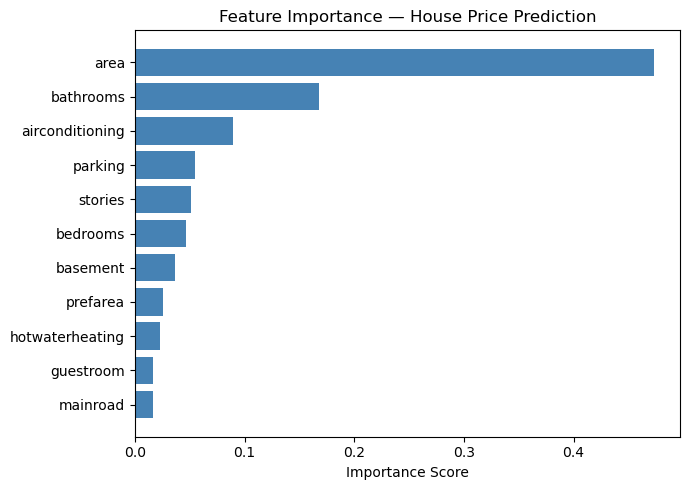

In [38]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)
plt.figure(figsize=(7,5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

# House Price Prediction Summary

- Loaded and explored dataset using pandas (`housingData`)
- Selected key features: area, bedrooms, bathrooms, stories, parking, and location/amenity-based features
- Created a clean working dataset (`predictionModel`)
- Converted categorical values (yes/no) into numerical format (1/0)
- Handled missing values using median imputation for numeric columns
- Performed EDA:
  - Price distribution is right-skewed (most houses are mid-range priced)
  - Area shows a positive relationship with price
- Trained a machine learning model using Gradient Boosting Regressor
- Split data into training (80%) and testing (20%)
- Evaluated model performance:
  - MAE ≈ 986,120
  - RMSE ≈ 1,331,352
  - R² ≈ 0.65 (model explains ~65% of price variation)
- Feature importance analysis showed:
  - Area is the most important factor
  - Bathrooms and air conditioning also strongly affect price
- Conclusion: Model performs moderately well and can be improved further with better tuning and feature engineering